In [2]:
import os

print(os.getcwd())

c:\Users\User.DESKTOP-G5S2APU\Desktop\rookies_06\python_webscraping\Python_WebScraping_Analysis_stu2026\연습문제


* 1. 지역별 총인구수 Top5


In [4]:
import pandas as pd

data = pd.read_csv('../data/인구현황.csv')

d_people = data.loc[
    data['행정기관'] != '전국',
    ['행정기관', '총인구수']
]\
.sort_values(
    by='총인구수',
    ascending=False
)\
.head(5)

d_people

,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


* 1-1 지역별 총인구수 plot

In [ ]:
import matplotlib.font_manager as fm
import matplotlib



#한글폰트 path 설정
[ (font.name, font.fname) for font in fm.fontManager.ttflist]
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'

#font의 파일정보로 font name 을 알아내기
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family = font_name)

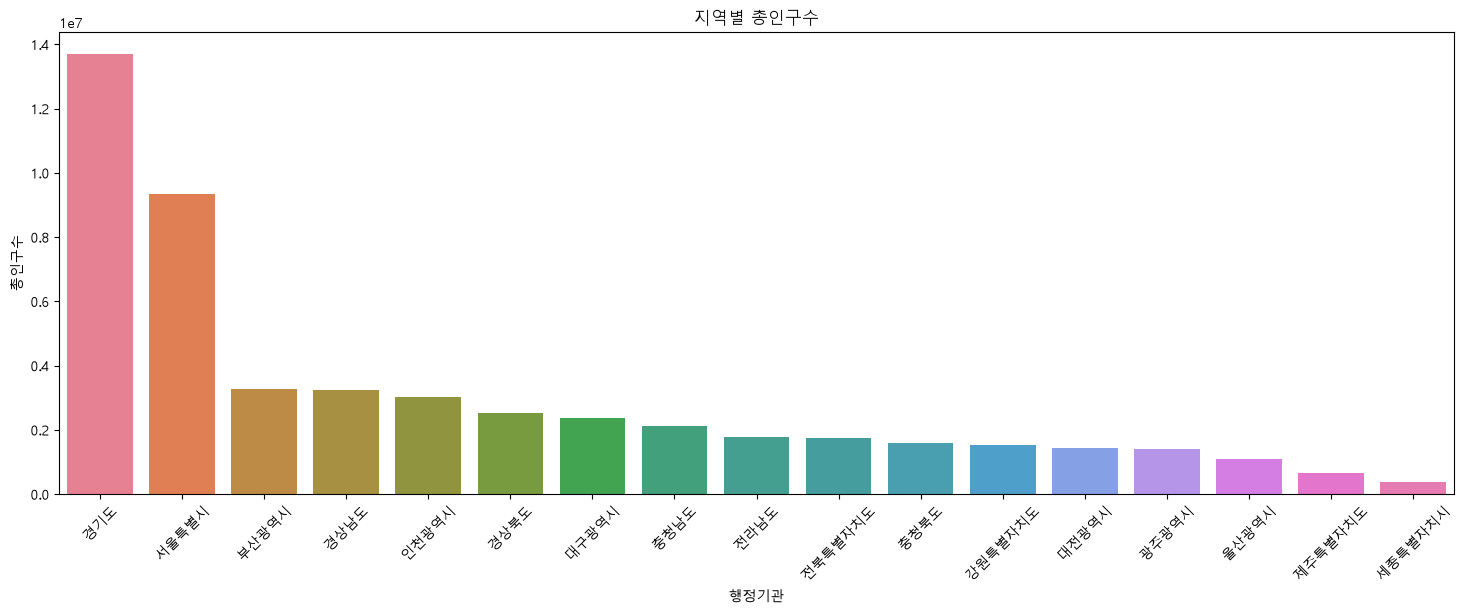

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data1 = pd.read_csv('../data/인구현황.csv')

d_people_all = data1.loc[
    data1['행정기관'] != '전국',
    ['행정기관', '총인구수']
].sort_values(
    by='총인구수',
    ascending=False
)

figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(18, 6)

sns.barplot(
    data=d_people_all,
    x='행정기관',
    y='총인구수',
    ax=axes1,
    hue='행정기관'
)

axes1.set_title('지역별 총인구수')
axes1.tick_params(axis='x', rotation=45)

plt.show()

* 2. 세대당 인구수 높은 지역 Top5

In [5]:
data = pd.read_csv('../data/인구현황.csv')
d_family = data.loc[
    data['행정기관'] != '전국',
    ['행정기관', '세대당 인구']
]\
.sort_values(
    by='세대당 인구',
    ascending=False
)\
.head(5)\
.reset_index(drop=True)

d_family


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


* 2-1. 지역별 세대당 인구 Plot

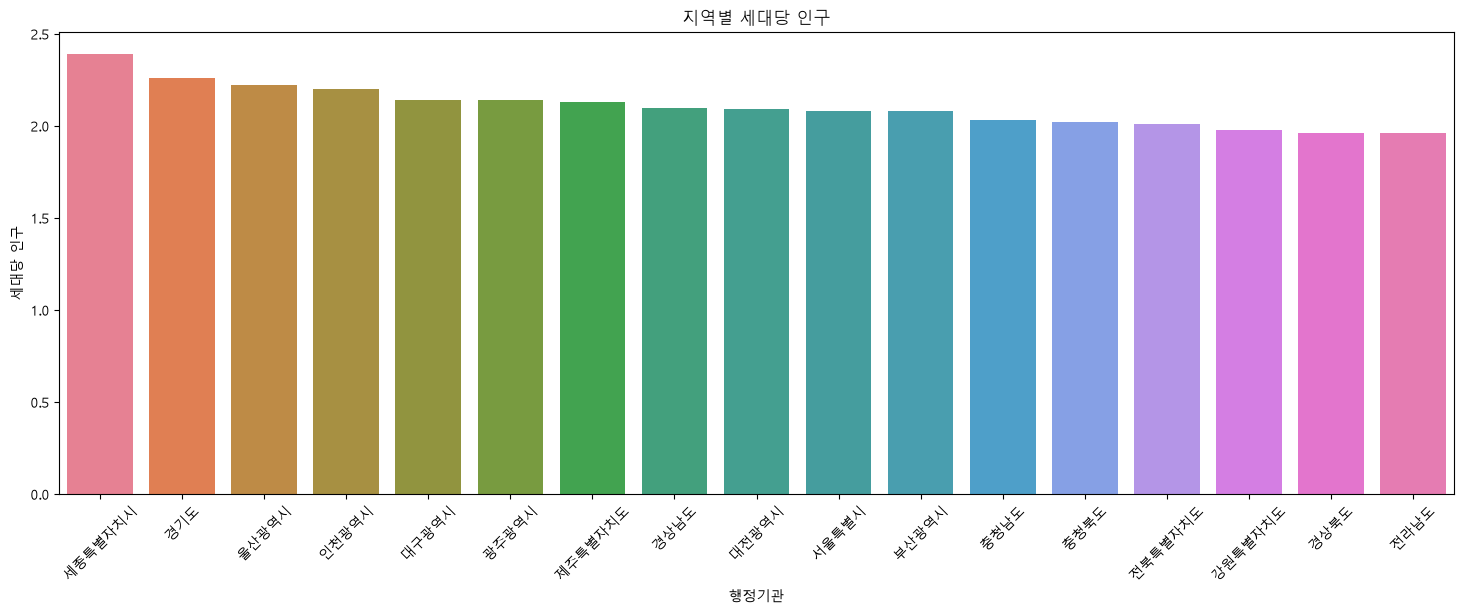

In [ ]:

data = pd.read_csv('../data/인구현황.csv')

# 전국을 제외하고 세대당 인구가 높은 순으로 정렬
d_family_all = data.loc[
    data['행정기관'] != '전국',
    ['행정기관', '세대당 인구']
]\
.sort_values(
    by='세대당 인구',
    ascending=False
)


# subplots() 함수를 사용하여 axes 객체 생성
figure, axes1 = plt.subplots(nrows=1, ncols=1)

figure.set_size_inches(18, 6)


# seaborn의 barplot() 함수 호출
sns.barplot(
    data=d_family_all,
    x='행정기관',
    y='세대당 인구',
    ax=axes1,
    hue='행정기관'
)


# 그래프 제목
axes1.set_title('지역별 세대당 인구')

# x축 글자 회전
axes1.tick_params(axis='x', rotation=45)

plt.show()

* 3. 남녀 비율분석

In [8]:

data = pd.read_csv('../data/인구현황.csv')
# 남여 비율 분석

d_gender = data.loc[
    data['행정기관'] != '전국',
    ['행정기관', '남여 비율']
]\
.sort_values(
    by='남여 비율',
    ascending=False
)\
.reset_index(drop=True)

d_gender

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,전라남도,1.02
4,경상북도,1.02
5,경상남도,1.02
6,강원특별자치도,1.01
7,경기도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


* 3-1. 남녀 비율 분석 Plot


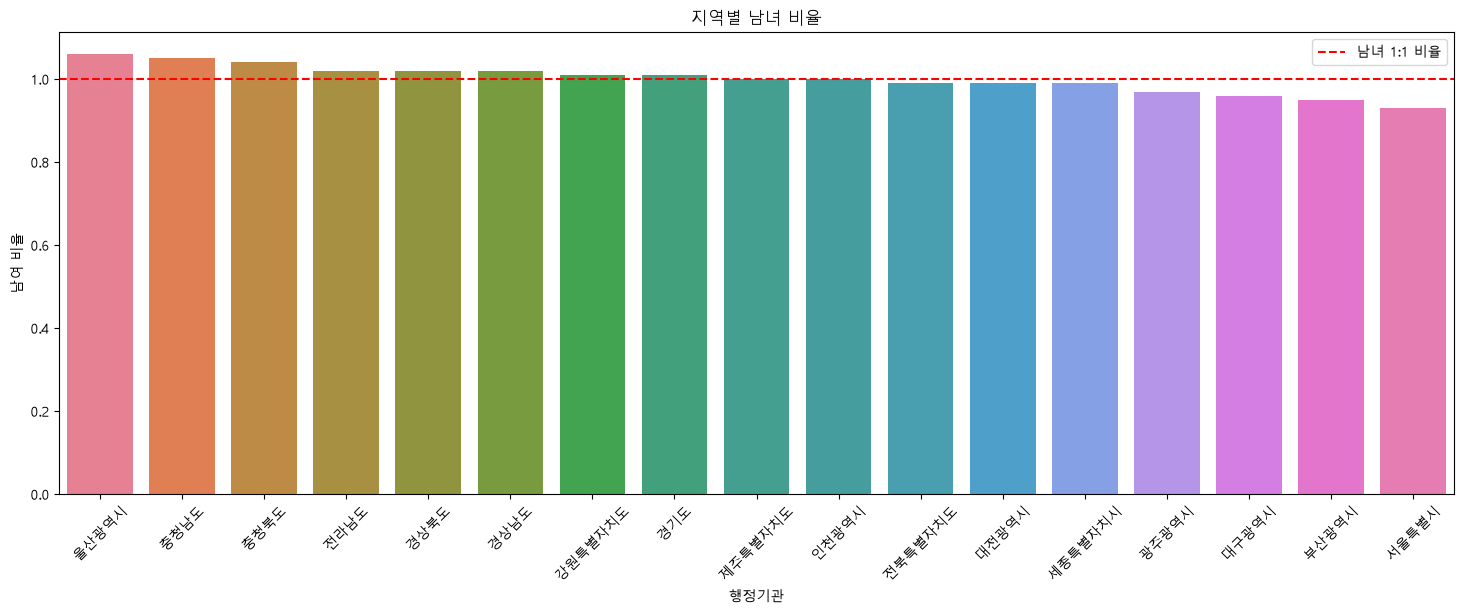

In [9]:
# subplots() 함수를 사용하여 axes 객체 생성
figure, axes1 = plt.subplots(nrows=1, ncols=1)

figure.set_size_inches(18, 6)


# 지역별 남녀 비율 barplot
sns.barplot(
    data=d_gender,
    x='행정기관',
    y='남여 비율',
    ax=axes1,
    hue='행정기관'
)


# 남녀 1:1 비율 기준선
axes1.axhline(
    y=1,
    color='red',
    linestyle='--',
    label='남녀 1:1 비율'
)


# 그래프 제목
axes1.set_title('지역별 남녀 비율')

# x축 글자 회전
axes1.tick_params(axis='x', rotation=45)

# 범례 표시
axes1.legend()

plt.show()

* 4. 남자초과 / 여자초과 분석

In [10]:
# 전국을 제외하고 필요한 컬럼 가져오기
d_gender_type = data.loc[
    data['행정기관'] != '전국',
    ['행정기관', '남여 비율']
].copy()


# 남초 / 여초 / 동일 구분
def gender_type(ratio):
    if ratio > 1:
        return '남초'
    elif ratio < 1:
        return '여초'
    else:
        return '동일'


# 남초여초 컬럼 추가
d_gender_type['남초여초'] = d_gender_type['남여 비율'].apply(gender_type)

d_gender_type

,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


* 5. 세대당 인구 평균보다 높은 지역

In [11]:
# 전국을 제외한 지역 데이터
region_data = data[data['행정기관'] != '전국']

# 전국 평균 세대당 인구수 계산
family_mean = region_data['세대당 인구'].mean()

print(f'전국 평균 세대당 인구수: {family_mean:.2f}')


# 평균보다 세대당 인구가 높은 지역
d_family_high = region_data.loc[
    region_data['세대당 인구'] > family_mean,
    ['행정기관', '세대당 인구']
]\
.sort_values(
    by='세대당 인구',
    ascending=False
)\
.reset_index(drop=True)

d_family_high

전국 평균 세대당 인구수: 2.11


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


* 5-1.   남초 vs 여초 개수 Plot  ( seaborn의 countplot )
         /지역별 세대수 Plot ( seaborn의 barplot )


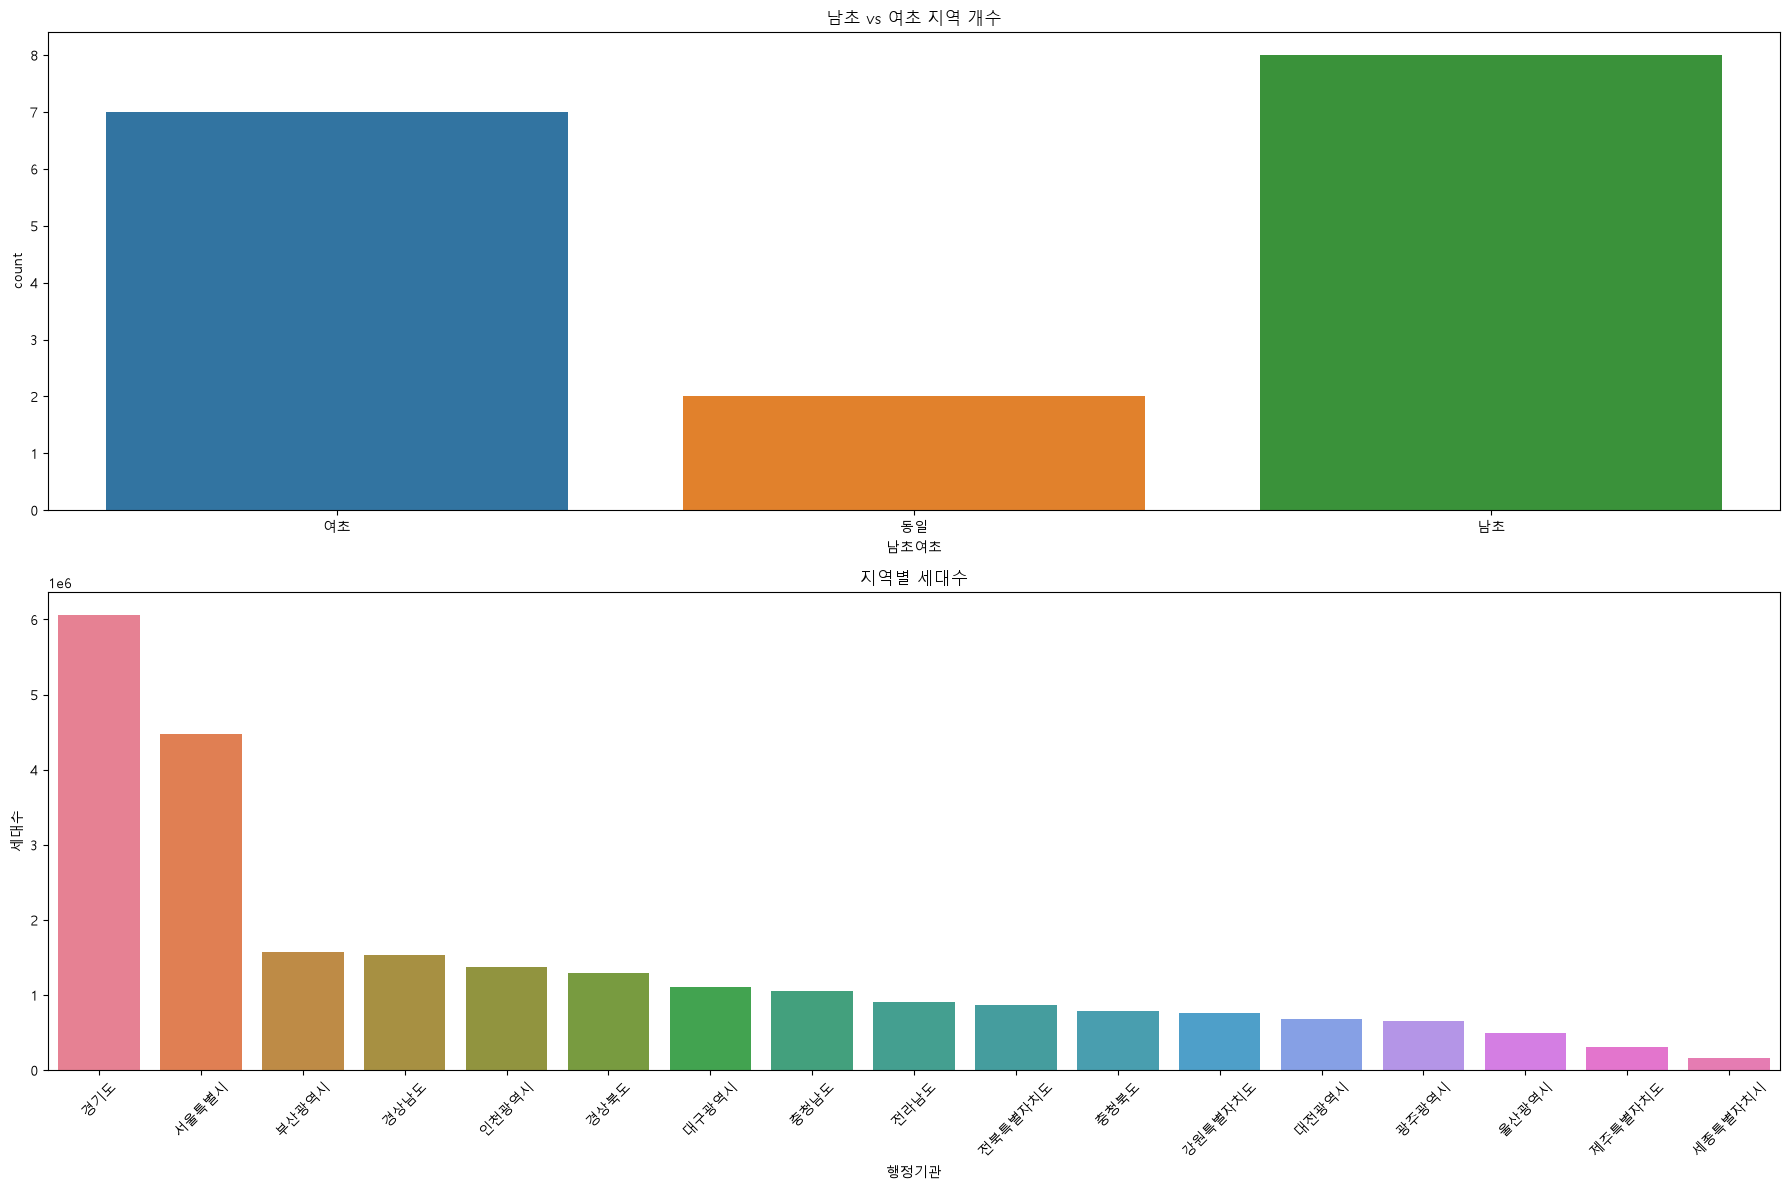

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


# subplots() 함수를 사용하여 axes 객체 2개 생성
figure, (axes1, axes2) = plt.subplots(nrows=2, ncols=1)

figure.set_size_inches(18, 12)


# 1. 남초 vs 여초 개수 Plot
sns.countplot(
    data=d_gender_type,
    x='남초여초',
    ax=axes1,
    hue='남초여초'
)

axes1.set_title('남초 vs 여초 지역 개수')
axes1.set_xlabel('남초여초')


# 2. 지역별 세대수 Plot
d_household = data.loc[
    data['행정기관'] != '전국'
].sort_values(
    by='세대수',
    ascending=False
)

sns.barplot(
    data=d_household,
    x='행정기관',
    y='세대수',
    ax=axes2,
    hue='행정기관'
)

axes2.set_title('지역별 세대수')
axes2.set_xlabel('행정기관')
axes2.set_ylabel('세대수')

axes2.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()